In [28]:
import pandas as pd

df = pd.read_csv("../data/raw/results.csv")

df.head()
df.info()
#df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 49328 entries, 0 to 49327
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49328 non-null  str    
 1   home_team   49328 non-null  str    
 2   away_team   49328 non-null  str    
 3   home_score  49256 non-null  float64
 4   away_score  49256 non-null  float64
 5   tournament  49328 non-null  str    
 6   city        49328 non-null  str    
 7   country     49328 non-null  str    
 8   neutral     49328 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [24]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    else:
        return "draw"

df["result"] = df.apply(get_result, axis=1)


df[["home_score", "away_score", "result"]].head()



,home_score,away_score,result
24061,2.0,1.0,home_win
24062,7.0,0.0,home_win
24063,0.0,0.0,draw
24064,1.0,1.0,draw
24065,1.0,1.0,draw


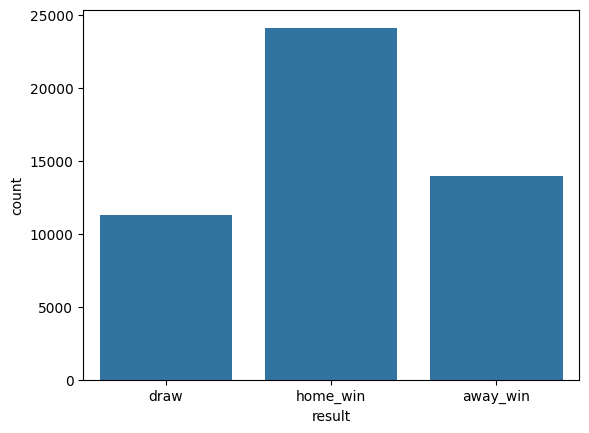

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="result")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df["date"] = pd.to_datetime(df["date"])

df = df[df["date"] >= "2000-01-01"]

df["goal_diff"] = df["home_score"] - df["away_score"]

mapping = {
    "home_win": 2,
    "draw": 1,
    "away_win": 0
}

df["target"] = df["result"].map(mapping)

home_df = df.copy()
away_df = df.copy()

# Invertimos perspectiva
away_df["home_team"], away_df["away_team"] = df["away_team"], df["home_team"]
away_df["home_score"], away_df["away_score"] = df["away_score"], df["home_score"]

# Recalcular target invertido
away_df["target"] = away_df["target"].map({2:0, 1:1, 0:2})

# Unimos
df_model = pd.concat([home_df, away_df], ignore_index=True)

df_model["neutral"] = df_model["neutral"].astype(int)

df_model["is_world_cup"] = (df_model["tournament"] == "FIFA World Cup").astype(int)
df_model["is_friendly"] = (df_model["tournament"] == "Friendly").astype(int)

team_counts = df_model["home_team"].value_counts()

df_model["team_experience"] = df_model["home_team"].map(team_counts)

features = [
    "neutral",
    "is_world_cup",
    "is_friendly",
    "team_experience"
]

df_model = df_model.sort_values("date")

split_date = "2018-01-01"

train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

model = RandomForestClassifier(n_estimators=100)

model.fit(train[features], train["target"])

preds = model.predict(test[features])

accuracy = accuracy_score(test["target"], preds)

print("Accuracy:", accuracy)


<class 'pandas.DataFrame'>
Index: 50534 entries, 0 to 50533
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             50534 non-null  datetime64[us]
 1   home_team        50534 non-null  str           
 2   away_team        50534 non-null  str           
 3   home_score       50390 non-null  float64       
 4   away_score       50390 non-null  float64       
 5   tournament       50534 non-null  str           
 6   city             50534 non-null  str           
 7   country          50534 non-null  str           
 8   neutral          50534 non-null  int64         
 9   result           50534 non-null  str           
 10  goal_diff        50390 non-null  float64       
 11  target           50534 non-null  int64         
 12  is_world_cup     50534 non-null  int64         
 13  is_friendly      50534 non-null  int64         
 14  team_experience  50534 non-null  int64         
dtypes